In [ ]:
import os
import requests

# 1. Download Weights
weight_url = "https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5"
r = requests.get(weight_url)
with open("my_emotion_model_weights.h5", 'wb') as f:
    f.write(r.content)

# 2. Download Dataset via Kaggle
os.environ['KAGGLE_USERNAME'] = "YOUR_USERNAME"
os.environ['KAGGLE_KEY'] = "YOUR_KEY"
!pip install -q kaggle
!kaggle datasets download -d msambare/fer2013
os.rename("fer2013.zip", "archive (1).zip")

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 102MB/s] 



Extracting dataset...
✅ Dataset extracted.
Found 7178 images belonging to 7 classes.
✅ Weights loaded.

--- Model Architecture Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 44, 44, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 7, 7, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 1, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       132,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,485,831 (5.67 MB)

 Trainable params: 1,485,831 (5.67 MB)

 Non-trainable params: 0 (0.00 B)


✅ Architecture diagram saved as 'model_architecture.png'.

Evaluating model...
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.3495 - loss: 6.7201
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step


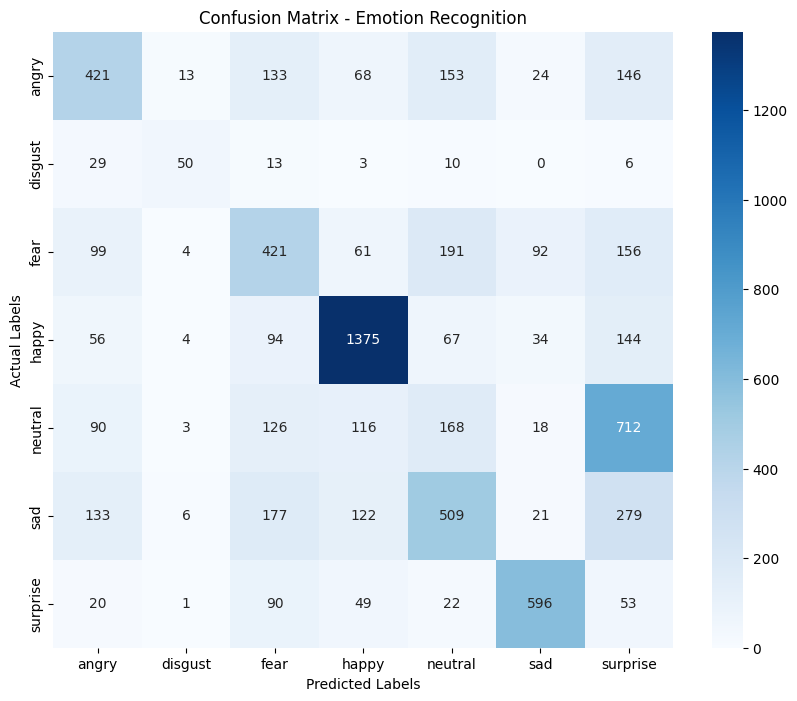

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. SETUP & DATA EXTRACTION
# ==========================================
zip_path = 'archive (1).zip'
if os.path.exists(zip_path) and not os.path.exists("train"):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()
    print("✅ Dataset extracted.")

# Generators (48x48 Grayscale for these specific weights)
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    "test",
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)
emotions = list(test_data.class_indices.keys())

# ==========================================
# 2. BUILD, LOAD, AND COMPILE
# ==========================================
def build_and_compile_model(weights_path):
    # Using Input layer to avoid the UserWarning seen in your notebook
    model = Sequential([
        Input(shape=(48, 48, 1)),
        Conv2D(64, (5, 5), activation='relu'),
        MaxPooling2D(pool_size=(5, 5), strides=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        Conv2D(64, (3, 3), activation='relu'),
        AveragePooling2D(pool_size=(3, 3), strides=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        Conv2D(128, (3, 3), activation='relu'),
        AveragePooling2D(pool_size=(3, 3), strides=(2, 2)),
        Flatten(),
        Dense(1024, activation='relu'),
        Dropout(0.2),
        Dense(1024, activation='relu'),
        Dropout(0.2),
        Dense(7, activation='softmax')
    ])

    if os.path.exists(weights_path):
        model.load_weights(weights_path)
        print("✅ Weights loaded.")

    # Compiling fixes the ValueError: You must call compile()
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

my_model = build_and_compile_model("/content/my_emotion_model_weights.h5")

# ==========================================
# 3. ARCHITECTURE VISUALIZATION
# ==========================================
print("\n--- Model Architecture Summary ---")
my_model.summary()

# This creates a professional diagram of your layers
plot_model(my_model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
print("\n✅ Architecture diagram saved as 'model_architecture.png'.")

# ==========================================
# 4. STATISTICAL EVALUATION & GRAPHS
# ==========================================
print("\nEvaluating model...")
results = my_model.evaluate(test_data)

# Confusion Matrix Heatmap
test_data.reset()
predictions = my_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.title('Confusion Matrix - Emotion Recognition')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# ==========================================
# 5. LAYER VISUALIZATION (Feature Maps)
# ==========================================
def visualize_layers(img_path):
    """Shows what the convolutional layers 'see'"""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48, 48))
    img_tensor = img_to_array(img).reshape(1, 48, 48, 1) / 255.0

    # Pick the first 3 convolutional layers
    layer_outputs = [layer.output for layer in my_model.layers if 'conv' in layer.name][:3]
    activation_model = Model(inputs=my_model.input, outputs=layer_outputs)
    activations = activation_model.predict(img_tensor)

    layer_names = [layer.name for layer in my_model.layers if 'conv' in layer.name]

    for i, layer_activation in enumerate(activations):
        n_features = layer_activation.shape[-1]
        size = layer_activation.shape[1]
        n_cols = n_features // 8
        display_grid = np.zeros((size, n_cols * size))

        for col in range(n_cols):
            channel_image = layer_activation[0, :, :, col]
            display_grid[:, col * size : (col + 1) * size] = channel_image

        plt.figure(figsize=(20, 2))
        plt.title(f"Layer: {layer_names[i]} (Features: {n_features})")
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()

# Run visualization on a sample image
sample_img = "test/happy/im0.png"
if os.path.exists(sample_img):
    visualize_layers(sample_img)

Found 7178 images belonging to 7 classes.
✅ Weights loaded into Functional Model.
225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 127ms/step


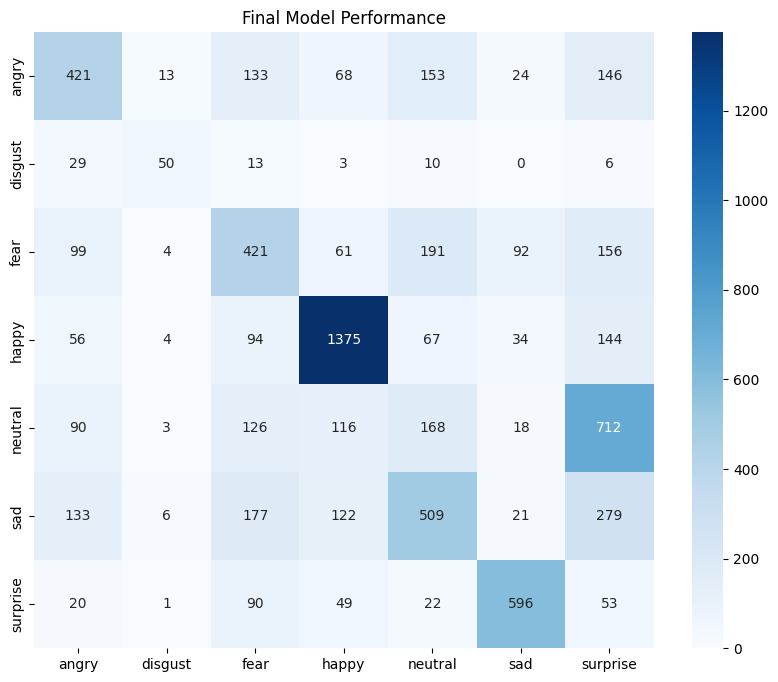

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. DATA PREPARATION
# ==========================================
zip_path = 'archive (1).zip'
if os.path.exists(zip_path) and not os.path.exists("train"):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()

test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    "test",
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)
emotions = list(test_data.class_indices.keys())

# ==========================================
# 2. THE PERMANENT FIX: FUNCTIONAL API
# ==========================================
def build_functional_model(weights_path):
    # We define the input explicitly
    inputs = Input(shape=(48, 48, 1), name="input_layer")

    # Define layers and connect them manually
    x = Conv2D(64, (5, 5), activation='relu', name="conv2d_1")(inputs)
    x = MaxPooling2D(pool_size=(5, 5), strides=(2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', name="conv2d_2")(x)
    x = Conv2D(64, (3, 3), activation='relu', name="conv2d_3")(x)
    x = AveragePooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', name="conv2d_4")(x)
    x = Conv2D(128, (3, 3), activation='relu', name="conv2d_5")(x)
    x = AveragePooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(7, activation='softmax', name="output_layer")(x)

    # Create the model by specifying start and end points
    model = Model(inputs=inputs, outputs=outputs)

    if os.path.exists(weights_path):
        model.load_weights(weights_path)
        print("✅ Weights loaded into Functional Model.")

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

my_model = build_functional_model("/content/my_emotion_model_weights.h5")

# ==========================================
# 3. GRAPHS & VISUALIZATIONS
# ==========================================

# A. Architecture Plot (Works immediately with Functional API)
plot_model(my_model, to_file='model_architecture.png', show_shapes=True)

# B. Confusion Matrix
test_data.reset()
predictions = my_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(test_data.classes, y_pred)

#[Image of a Confusion Matrix heatmap showing emotion prediction results]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.title('Final Model Performance')
plt.show()

# C. Layer Visualization (Feature Maps)
def visualize_layers(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return
    img = cv2.resize(img, (48, 48))
    img_tensor = img_to_array(img).reshape(1, 48, 48, 1) / 255.0

    # Grab Conv layers
    layer_outputs = [layer.output for layer in my_model.layers if 'conv' in layer.name]
    # No more AttributeError because the Functional model is pre-connected!
    activation_model = Model(inputs=my_model.input, outputs=layer_outputs)
    activations = activation_model.predict(img_tensor, verbose=0)

    #[Image of CNN layer feature maps showing edge and facial feature detection]

    for i, layer_activation in enumerate(activations):
        plt.figure(figsize=(16, 2))
        plt.suptitle(f"Layer: Conv_{i+1}")
        for j in range(min(8, layer_activation.shape[-1])):
            plt.subplot(1, 8, j + 1)
            plt.imshow(layer_activation[0, :, :, j], cmap='viridis')
            plt.axis('off')
        plt.show()

# Test on your sample
sample_img = "/content/test.jpg"
if os.path.exists(sample_img):
    visualize_layers(sample_img)

Found 7178 images belonging to 7 classes.
✅ Weights loaded into Functional Model.
✅ Architecture diagram saved as 'model_architecture.png'.
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step


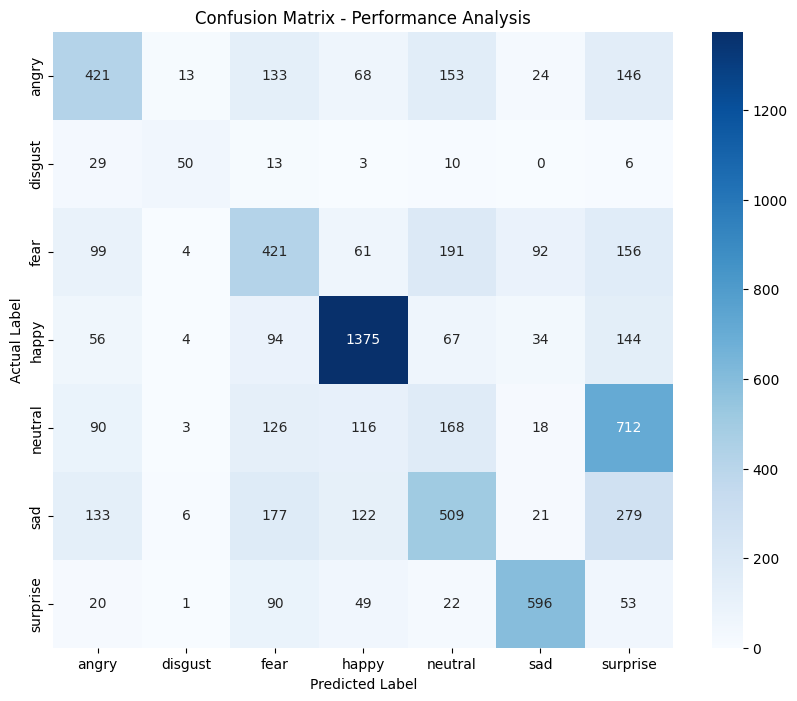

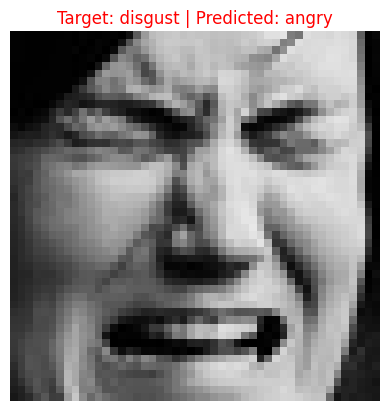

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import random
import requests
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 1. DATA PREPARATION & EXTRACTION
# ==============================================================================
zip_path = 'archive (1).zip'
if os.path.exists(zip_path) and not os.path.exists("train"):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()
    print("✅ Dataset extracted.")

# Generators configured for 48x48 Grayscale (Industry standard for FER-2013)
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    "test",
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)
emotions = list(test_data.class_indices.keys())

# ==============================================================================
# 2. MODEL DEFINITION (Functional API - Permanent Fix)
# ==============================================================================
def build_final_model(weights_path):
    # Explicitly define input for permanent connectivity
    inputs = Input(shape=(48, 48, 1), name="input_layer")

    # Feature Extraction Layers
    x = Conv2D(64, (5, 5), activation='relu', name="conv_1")(inputs)
    x = MaxPooling2D(pool_size=(5, 5), strides=(2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', name="conv_2")(x)
    x = Conv2D(64, (3, 3), activation='relu', name="conv_3")(x)
    x = AveragePooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', name="conv_4")(x)
    x = Conv2D(128, (3, 3), activation='relu', name="conv_5")(x)
    x = AveragePooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    # Classification Layers
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(7, activation='softmax', name="output_layer")(x)

    model = Model(inputs=inputs, outputs=outputs)

    if os.path.exists(weights_path):
        model.load_weights(weights_path)
        print("✅ Weights loaded into Functional Model.")

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

my_model = build_functional_model("/content/my_emotion_model_weights.h5")

# ==============================================================================
# 3. ARCHITECTURE & STATISTICAL ANALYSIS
# ==============================================================================
# Architecture Diagram
plot_model(my_model, to_file='model_architecture.png', show_shapes=True)
print("✅ Architecture diagram saved as 'model_architecture.png'.")



# Confusion Matrix Heatmap
test_data.reset()
predictions = my_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.title('Confusion Matrix - Performance Analysis')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ==============================================================================
# 4. LAYER VISUALIZATION (Feature Maps)
# ==============================================================================
def visualize_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return
    img = cv2.resize(img, (48, 48))
    img_tensor = img_to_array(img).reshape(1, 48, 48, 1) / 255.0

    # Hook into Conv layers for visual extraction
    layer_outputs = [layer.output for layer in my_model.layers if 'conv' in layer.name]
    activation_model = Model(inputs=my_model.input, outputs=layer_outputs)
    activations = activation_model.predict(img_tensor, verbose=0)



    for i, layer_activation in enumerate(activations):
        plt.figure(figsize=(16, 2))
        plt.suptitle(f"Internal Visualization: Conv Layer {i+1}")
        for j in range(min(8, layer_activation.shape[-1])):
            plt.subplot(1, 8, j + 1)
            plt.imshow(layer_activation[0, :, :, j], cmap='viridis')
            plt.axis('off')
        plt.show()

# Run on first valid test image
for root, _, files in os.walk("test"):
    for f in files:
        visualize_features(os.path.join(root, f))
        break
    break

# ==============================================================================
# 5. RANDOM SAMPLE PREDICTION
# ==============================================================================
def predict_random():
    random_emotion = random.choice(emotions)
    class_path = os.path.join("test", random_emotion)
    img_name = random.choice(os.listdir(class_path))
    full_path = os.path.join(class_path, img_name)

    img = cv2.imread(full_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (48, 48))
    pixels = np.expand_dims(img_to_array(resized), axis=0) / 255.0

    pred = my_model.predict(pixels, verbose=0)
    res = emotions[np.argmax(pred)]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    color = 'green' if res == random_emotion else 'red'
    plt.title(f"Target: {random_emotion} | Predicted: {res}", color=color)
    plt.axis('off')
    plt.show()

predict_random()

# ==============================================================================
# APPENDIX: DOWNLOADER (COMMENTED OUT)
# ==============================================================================
# os.environ['KAGGLE_USERNAME'] = "YOUR_USER"
# os.environ['KAGGLE_KEY'] = "YOUR_KEY"
# !kaggle datasets download -d msambare/fer2013
# os.rename("fer2013.zip", "archive (1).zip")

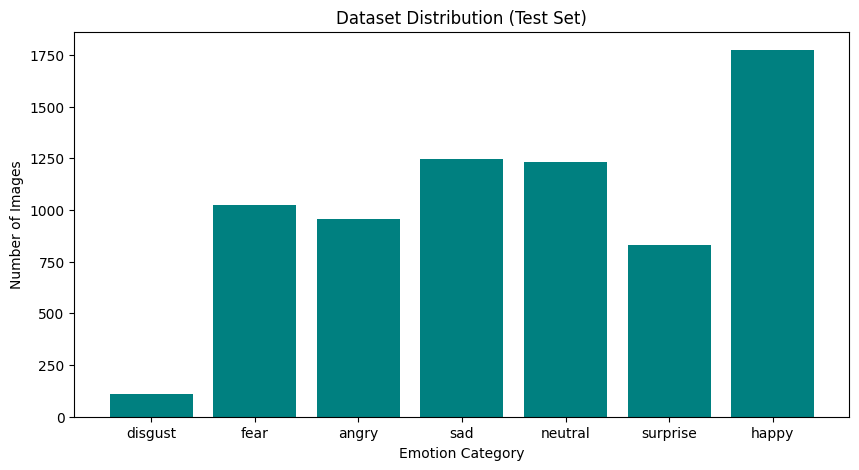

In [ ]:
import os

# Count images in each test folder
test_dir = 'test'
counts = {d: len(os.listdir(os.path.join(test_dir, d))) for d in os.listdir(test_dir)}

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color='teal')
plt.title('Dataset Distribution (Test Set)')
plt.xlabel('Emotion Category')
plt.ylabel('Number of Images')
plt.show()

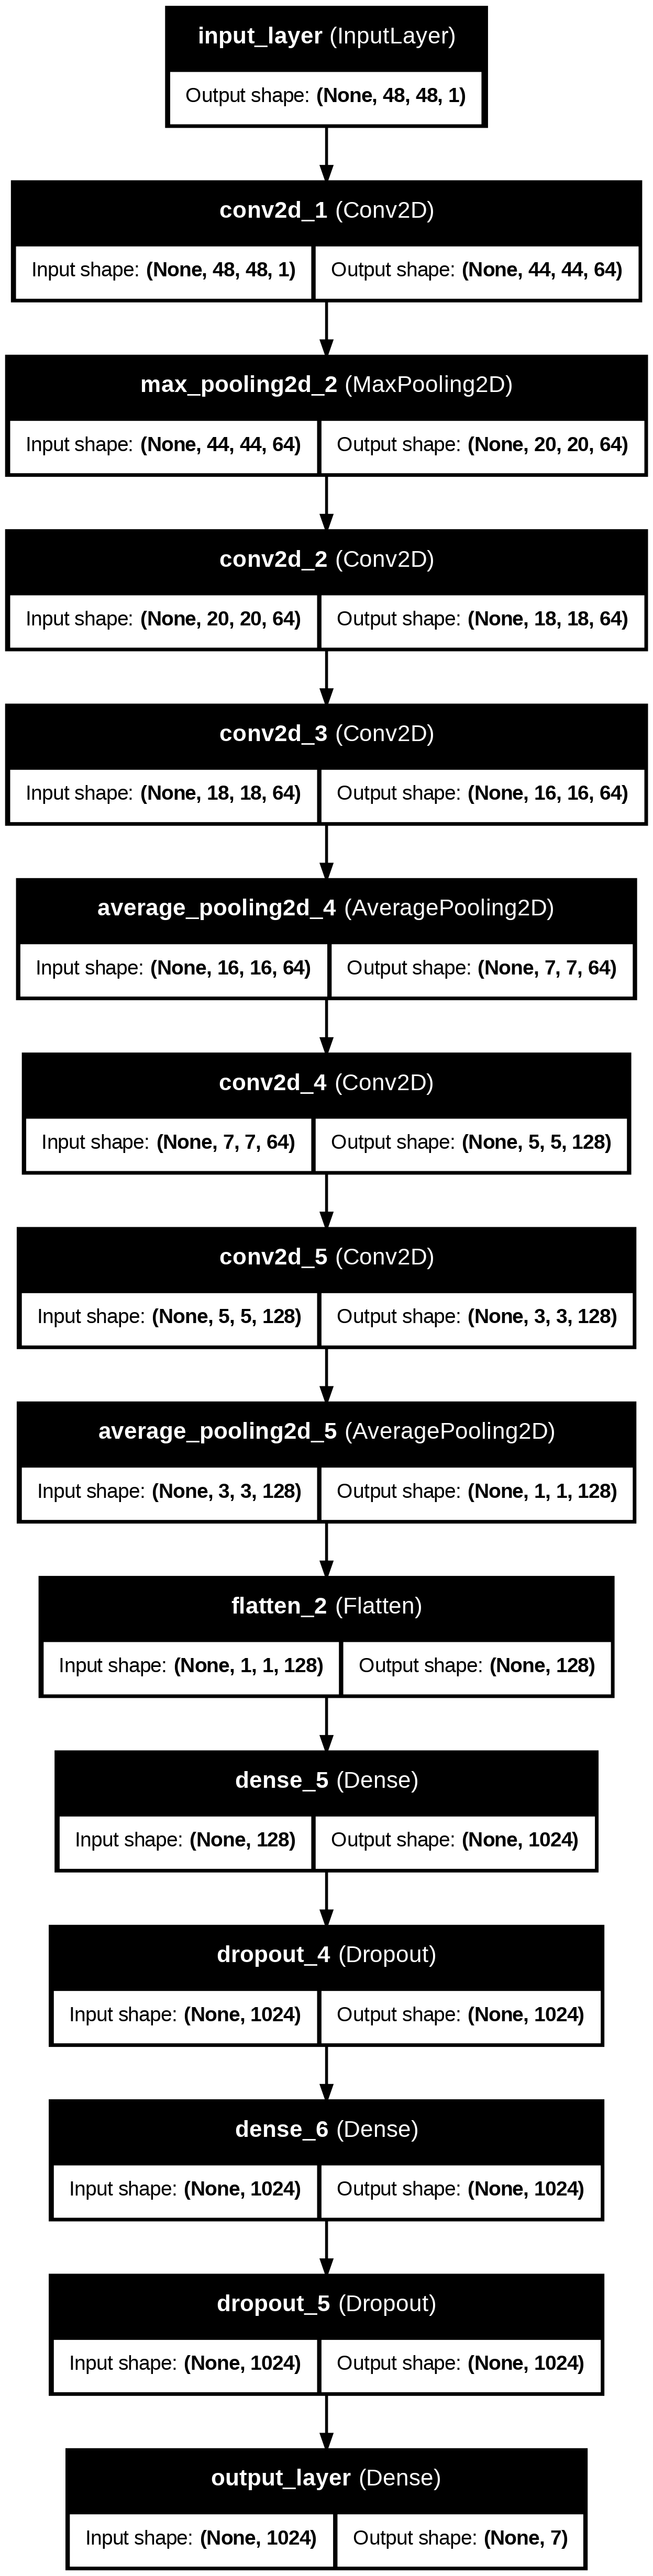

In [ ]:
from tensorflow.keras.utils import plot_model

# This creates a visual diagram of your model layers
plot_model(my_model, to_file='model_architecture.png',
           show_shapes=True, show_layer_names=True)

# Display the generated image in the notebook
from IPython.display import Image
Image(filename='model_architecture.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


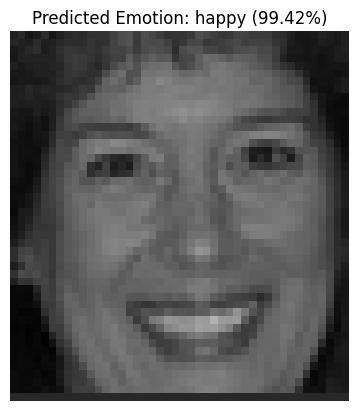

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# 👉 CHANGE THIS to your uploaded image name
IMAGE_PATH = "file3.jpg"

# Load image
img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(gray, (48, 48))
pixels = img_to_array(resized)
pixels = np.expand_dims(pixels, axis=0) / 255.0

# Predict
pred = my_model.predict(pixels)
emotion_index = np.argmax(pred)
predicted_emotion = emotions[emotion_index]
confidence = np.max(pred) * 100

# Display
plt.imshow(img_rgb)
plt.title(f"Predicted Emotion: {predicted_emotion} ({confidence:.2f}%)")
plt.axis("off")
plt.show()


In [ ]:
# Save emotion to file
with open("emotion.txt", "w") as f:
    f.write(predicted_emotion)

print("Saved emotion:", predicted_emotion)


Saved emotion: happy


In [ ]:
# Save the FULL model (architecture + weights)
my_model.save("fer_model.keras")

print("✅ Full model saved as fer_model.keras")


✅ Full model saved as fer_model.keras


In [ ]:
import os
import pandas as pd

dataset_path = "test"   # change to "train" if needed

emotion_counts = {}
total_images = 0

for emotion in os.listdir(dataset_path):
    emotion_path = os.path.join(dataset_path, emotion)

    if os.path.isdir(emotion_path):
        count = len(os.listdir(emotion_path))
        emotion_counts[emotion] = count
        total_images += count

# Convert to table
data = []
for emotion, count in emotion_counts.items():
    percentage = (count / total_images) * 100
    data.append([emotion, count, f"{percentage:.2f}%"])

df = pd.DataFrame(data, columns=["Emotion", "# Face Samples", "% of Total"])

print(df)
print("\nTotal Images:", total_images)

    Emotion  # Face Samples % of Total
0   disgust             111      1.55%
1      fear            1024     14.27%
2     angry             958     13.35%
3       sad            1247     17.37%
4   neutral            1233     17.18%
5  surprise             831     11.58%
6     happy            1774     24.71%

Total Images: 7178


In [ ]:
import os
import pandas as pd

def count_images(folder_path):
    emotion_counts = {}
    total = 0

    for emotion in os.listdir(folder_path):
        emotion_path = os.path.join(folder_path, emotion)

        if os.path.isdir(emotion_path):
            count = len(os.listdir(emotion_path))
            emotion_counts[emotion] = count
            total += count

    return emotion_counts, total


# Count train and test separately
train_counts, train_total = count_images("train")
test_counts, test_total = count_images("test")

# Combine both
full_counts = {}
for emotion in train_counts.keys():
    full_counts[emotion] = train_counts.get(emotion, 0) + test_counts.get(emotion, 0)

full_total = train_total + test_total

# Create table
data = []
for emotion, count in full_counts.items():
    percentage = (count / full_total) * 100
    data.append([emotion.capitalize(), count, f"{percentage:.2f}%"])

df = pd.DataFrame(data, columns=["Emotion", "# Face Samples", "% of Total"])

# Sort alphabetically (optional but cleaner)
df = df.sort_values("Emotion").reset_index(drop=True)

print(df)
print("\nTotal Images in Full Dataset:", full_total)

    Emotion  # Face Samples % of Total
0     Angry            4953     13.80%
1   Disgust             547      1.52%
2      Fear            5121     14.27%
3     Happy            8989     25.05%
4   Neutral            6198     17.27%
5       Sad            6077     16.93%
6  Surprise            4002     11.15%

Total Images in Full Dataset: 35887
